# 07: Topic Modeling of NWSL Media Coverage

Tags each NWSL article with its dominant LDA topic and analyzes how topic frequency changes over time, then looks at which topics dominate the coverage spikes identified in `06_media_trends_analysis.ipynb`.

Uses the shared color theme in `plot_theme.py` so every chart in this repo reads as part of the same project.

**Inputs:** `data/processed/nwsl_articles_filtered.csv`, `data/processed/monthly_peaks.csv`, `data/processed/daily_peaks.csv`
**Outputs:** `data/processed/nwsl_articles_tagged.csv`, `data/processed/nwsl_topic_counts_by_year.csv`, `nwsl_topic_proportions_by_year.csv`, `nwsl_topic_counts_by_month.csv`, `nwsl_topic_proportions_by_month.csv`, `nwsl_daily_peaks_tagged.csv`, `nwsl_monthly_peaks_tagged.csv`, `nwsl_peak_topic_proportions.csv`; figures saved to `output/`


## 1. Imports and settings

In [1]:
import pandas as pd
import numpy as np
import os
import random

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
from nltk.tokenize import wordpunct_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from gensim import corpora
import gensim

import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
pyLDAvis.enable_notebook()

import matplotlib.pyplot as plt

from plot_theme import set_mpl_theme, NWSL_PALETTE

random.seed(42)
set_mpl_theme()

DATA_PROCESSED_DIR = os.path.join("..", "data", "processed")
OUTPUT_DIR = os.path.join("..", "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

NUM_TOPICS = 4 # 5 brings in overlap, 3 is all vague


## 2. Load data

In [2]:
df = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "nwsl_articles_filtered.csv"))
print(df.shape)

df["publish_date"] = pd.to_datetime(df["publish_date"], errors="coerce")
df["pub_year"] = df["publish_date"].dt.year
df["pub_yearmonth"] = df["publish_date"].dt.to_period("M")

n_bad_dates = df["publish_date"].isna().sum()
if n_bad_dates:
    print(f"Warning: {n_bad_dates} rows have an unparseable publish_date and "
          f"will be dropped from the time-series analysis.")


(8328, 4)


## 3. Preprocess titles

Domain-specific stopwords (team names/nicknames, generic league/game words, headline filler) are added on top of NLTK's English stopword list, then titles are tokenized and Porter-stemmed.


In [3]:
list_stopwords = stopwords.words("english")

custom_words_toadd = [
    # generic league/game words
    "nwsl", "soccer", "league", "national", "women's", "womens",
    "vs", "game", "match", "women",
    # team names / nicknames (stemmed forms will match e.g. "thorn" from "thorns")
    "thorn", "thorns", "pride", "portland", "gotham", "orlando",
    "spirit", "washington", "wave", "san", "diego", "chicago",
    "reign", "star", "stars", "angel", "angels", "city",
    "courage", "current", "kc", "louisville", "bay", "utah", "breakers",
    "houston", "dash", "north", "carolina", "racing", "sky blue", "legacy",
    # generic filler / meta words that show up in headlines but aren't meaningful
    "watch", "live", "stream", "time", "new", "top", "world",
]

list_stopwords_new = list_stopwords + custom_words_toadd
porter = PorterStemmer()


def rm_stop(raw: str):
    return [word for word in wordpunct_tokenize(raw) if word not in list_stopwords_new]


def get_stem(raw: list):
    return [porter.stem(token) for token in raw if token.isalpha() and len(token) > 2]


def rm_stop_and_stem(raw: str):
    if type(raw) is not str:
        return None
    return get_stem(rm_stop(raw))


df["title_lower"] = df["title"].str.lower()
df["processed_text"] = df["title_lower"].apply(rm_stop_and_stem)


## 4. Build the gensim dictionary/corpus and estimate the LDA model

In [4]:
has_tokens = df["processed_text"].apply(lambda x: isinstance(x, list) and len(x) > 0)
model_df = df.loc[has_tokens].copy()
docs = model_df["processed_text"].tolist()

text_dict = corpora.Dictionary(docs)
raw_len = len(text_dict)

lower_bound = max(2, round(len(docs) * 0.01))
upper_bound = round(len(docs) * 0.90)
text_dict.filter_extremes(no_below=lower_bound, no_above=upper_bound)
print(f"Dictionary filtered from {raw_len} to {len(text_dict)} terms.")

corpus_fromdict = [text_dict.doc2bow(one_text) for one_text in docs]

ldamod = gensim.models.ldamodel.LdaModel(
    corpus_fromdict,
    num_topics=NUM_TOPICS,
    id2word=text_dict,
    passes=10,
    alpha="auto",
    per_word_topics=True,
    random_state=42,
)

topics = ldamod.print_topics(num_words=10)
print("\nTopics discovered:")
for topic in topics:
    print(topic)


Dictionary filtered from 5076 to 101 terms.



Topics discovered:
(0, '0.156*"draft" + 0.101*"expans" + 0.063*"pick" + 0.062*"goal" + 0.055*"report" + 0.055*"record" + 0.053*"set" + 0.052*"draw" + 0.050*"get" + 0.049*"return"')
(1, '0.195*"team" + 0.141*"player" + 0.100*"coach" + 0.052*"name" + 0.051*"deal" + 0.041*"trade" + 0.034*"join" + 0.031*"head" + 0.031*"say" + 0.028*"former"')
(2, '0.103*"cup" + 0.094*"season" + 0.071*"sign" + 0.063*"final" + 0.060*"red" + 0.053*"year" + 0.039*"challeng" + 0.039*"club" + 0.039*"open" + 0.036*"announc"')
(3, '0.092*"win" + 0.085*"championship" + 0.072*"rapino" + 0.068*"uswnt" + 0.055*"megan" + 0.051*"first" + 0.040*"score" + 0.038*"playoff" + 0.036*"titl" + 0.033*"end"')


In [5]:
lda_display = gensimvis.prepare(ldamod, corpus_fromdict, text_dict)
pyLDAvis.display(lda_display)

In [6]:
# Human-readable labels, assigned after inspecting the top words above
TOPIC_LABELS = {
    0: "Team/League Updates",
    1: "Coaching Updates & Contraversies",
    2: "Schedules & Power Rankings",
    3: "How to Watch",
}

# Fixed color per topic label (from the shared NWSL_PALETTE)
TOPIC_COLORS = {
    label: NWSL_PALETTE[i % len(NWSL_PALETTE)]
    for i, label in enumerate(TOPIC_LABELS.values())
}


## 5. Tag each article with its dominant topic + full probability vector

In [7]:
doc_topic_dists = [
    ldamod.get_document_topics(bow, minimum_probability=0.0) for bow in corpus_fromdict
]

# sort into id-order
topic_prob_matrix = np.zeros((len(doc_topic_dists), NUM_TOPICS))
for i, dist in enumerate(doc_topic_dists):
    for topic_id, prob in dist:
        topic_prob_matrix[i, topic_id] = prob

dominant_topic = topic_prob_matrix.argmax(axis=1)
dominant_topic_prob = topic_prob_matrix.max(axis=1)

for t in range(NUM_TOPICS):
    model_df[f"topic_{t}_prob"] = topic_prob_matrix[:, t]

model_df["dominant_topic"] = dominant_topic
model_df["dominant_topic_prob"] = dominant_topic_prob
model_df["dominant_topic_label"] = model_df["dominant_topic"].map(TOPIC_LABELS)

tag_cols = ["dominant_topic", "dominant_topic_prob", "dominant_topic_label"] + [
    f"topic_{t}_prob" for t in range(NUM_TOPICS)
]
df = df.join(model_df[tag_cols])

print(f"\nTagged {model_df.shape[0]} of {df.shape[0]} articles "
      f"({df.shape[0] - model_df.shape[0]} had no usable tokens after preprocessing).")

tagged_path = os.path.join(DATA_PROCESSED_DIR, "nwsl_articles_tagged.csv")
df.to_csv(tagged_path, index=False)
print(f"Saved tagged articles to {tagged_path}")



Tagged 8318 of 8328 articles (10 had no usable tokens after preprocessing).
Saved tagged articles to ../data/processed/nwsl_articles_tagged.csv


In [8]:
# Check if titles seem correctly categorized
print("Top example titles per topic (highest topic probability):")
for t in range(NUM_TOPICS):
    print(f"\n--- Topic {t} ({TOPIC_LABELS[t]}) ---")
    top_examples = model_df.sort_values(f"topic_{t}_prob", ascending=False).head(5)
    for _, row in top_examples.iterrows():
        print(f"  [{row[f'topic_{t}_prob']:.2f}] {row['title']}")

Top example titles per topic (highest topic probability):

--- Topic 0 (Team/League Updates) ---
  [0.75] US women's soccer star Alex Morgan: 'Time to take a stand' for pay equality
  [0.75] Orlando Pride cede late equalizer, draw Sky Blue FC as Sydney Leroux returns
  [0.71] San Diego and Angel City battle to scoreless draw as Alex Morgan returns to Wave lineup
  [0.71] Tobin Heath’s highlight-reel goal helps Portland Thorns rally for 2-2 draw at Sky Blue FC
  [0.70] Alex Morgan gets confidence boost after netting first Orlando Pride goal of 2018

--- Topic 1 (Coaching Updates & Contraversies) ---
  [0.78] Head of NWSL players union says sex abuse allegations tied to systemic problem
  [0.78] Former OL Reign coach Farid Benstiti resigned after allegations of abusive comments, NWSL commissioner ousted
  [0.78] National Women's Soccer League commissioner resigns amid misconduct allegations against prominent former coach
  [0.78] Calvin College names Emily Ottenhoff head women's soccer c

## 6. Aggregate topic frequency over time

In [9]:
tagged = df.loc[df["dominant_topic"].notna()].copy()
tagged["dominant_topic"] = tagged["dominant_topic"].astype(int)

# 6.1 Counts + proportions per year per topic
yearly_counts = (
    tagged.groupby(["pub_year", "dominant_topic"]).size().unstack(fill_value=0).sort_index()
)
yearly_counts.columns = [TOPIC_LABELS[c] for c in yearly_counts.columns]
# print("Article counts per topic per year:")
# print(yearly_counts)

yearly_props = yearly_counts.div(yearly_counts.sum(axis=1), axis=0)
# print("\nTopic proportions per year:")
# print(yearly_props.round(3))

yearly_counts.to_csv(os.path.join(DATA_PROCESSED_DIR, "nwsl_topic_counts_by_year.csv"))
yearly_props.to_csv(os.path.join(DATA_PROCESSED_DIR, "nwsl_topic_proportions_by_year.csv"))
print("\nSaved nwsl_topic_counts_by_year.csv and nwsl_topic_proportions_by_year.csv")

# 6.2 Same aggregation at monthly granularity, for a finer-grained view
monthly_counts = (
    tagged.groupby(["pub_yearmonth", "dominant_topic"]).size().unstack(fill_value=0).sort_index()
)
monthly_counts.columns = [TOPIC_LABELS[c] for c in monthly_counts.columns]
monthly_props = monthly_counts.div(monthly_counts.sum(axis=1), axis=0)

monthly_counts.to_csv(os.path.join(DATA_PROCESSED_DIR, "nwsl_topic_counts_by_month.csv"))
monthly_props.to_csv(os.path.join(DATA_PROCESSED_DIR, "nwsl_topic_proportions_by_month.csv"))
print("Saved nwsl_topic_counts_by_month.csv and nwsl_topic_proportions_by_month.csv")



Saved nwsl_topic_counts_by_year.csv and nwsl_topic_proportions_by_year.csv
Saved nwsl_topic_counts_by_month.csv and nwsl_topic_proportions_by_month.csv


## 7. Plot topic trends over time

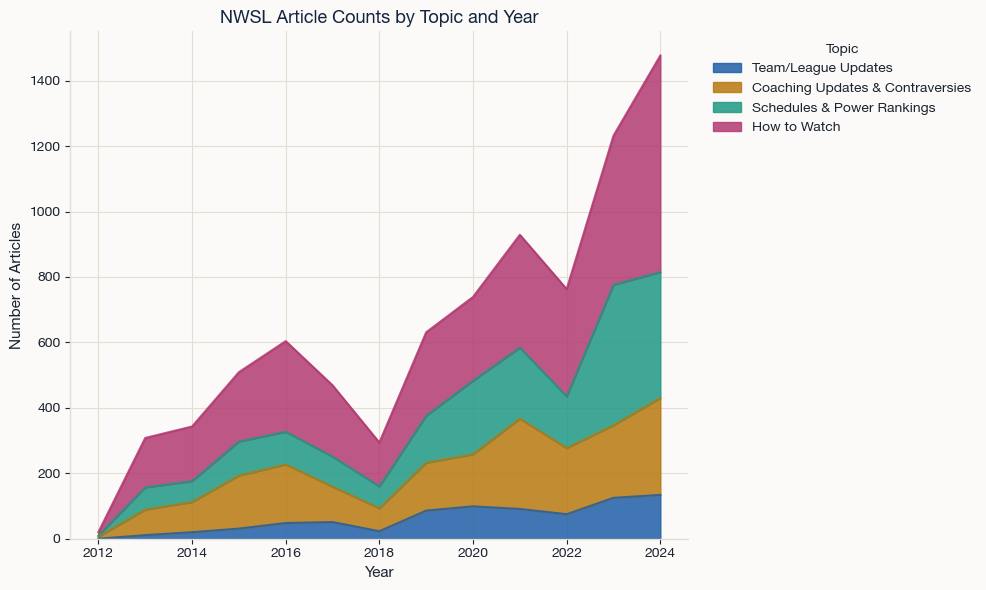

In [10]:
# 7.1 Raw counts by year (stacked area)
fig, ax = plt.subplots(figsize=(10, 6))
yearly_counts.plot(
    kind="area", stacked=True, ax=ax, alpha=0.85,
    color=[TOPIC_COLORS[c] for c in yearly_counts.columns],
)
ax.set_title("NWSL Article Counts by Topic and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Articles")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nwsl_topic_counts_by_year.png"), dpi=150)
plt.show()
plt.close(fig)


## 7b. Annotated version for the site

Same chart as 7.1, with narrative callouts marking the real-world events behind the biggest swings in coverage volume. Saved to `output/` and directly into the site's asset folder so the published figure always matches this code.


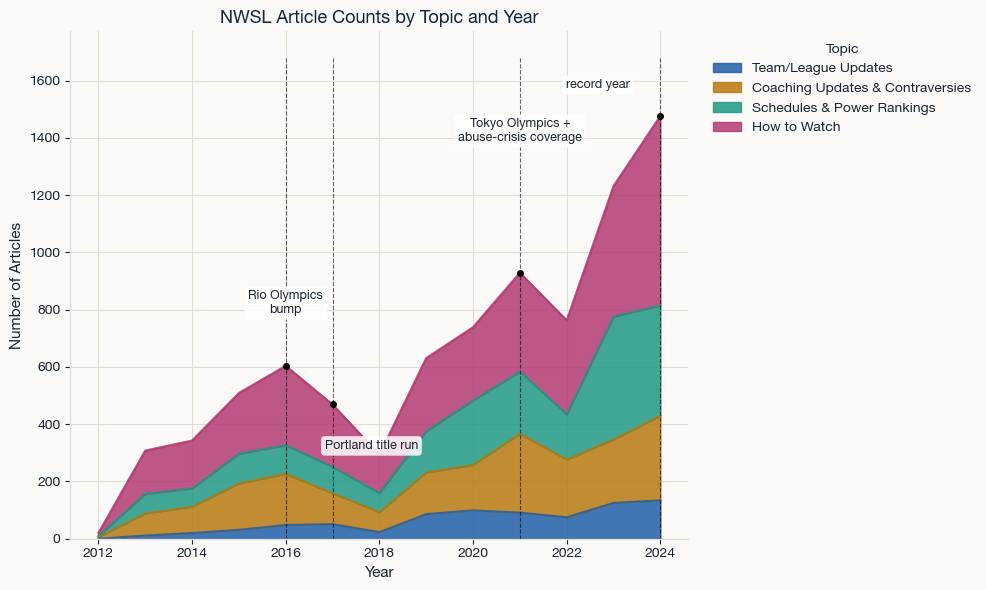

Saved nwsl_topic_counts_by_year_annotated.png to output/ and topic-mix-by-year.png to site/src/assets/figures/


In [11]:
SITE_FIGURES_DIR = os.path.join("..", "site", "src", "assets", "figures")

year_totals = yearly_counts.sum(axis=1)

# (year, label, (x-offset pts, y-offset pts))
TOPIC_YEAR_ANNOTATIONS = [
    (2016, "Rio Olympics\nbump", (0, 38)),
    (2017, "Portland title run", (28, -32)),
    (2021, "Tokyo Olympics +\nabuse-crisis coverage", (0, 95)),
    (2024, "record year", (-45, 20)),
]

fig, ax = plt.subplots(figsize=(10, 6))
yearly_counts.plot(
    kind="area", stacked=True, ax=ax, alpha=0.85,
    color=[TOPIC_COLORS[c] for c in yearly_counts.columns],
)
ax.set_title("NWSL Article Counts by Topic and Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Articles")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left")

for year, label, (dx, dy) in TOPIC_YEAR_ANNOTATIONS:
    y = year_totals.loc[year]
    ax.axvline(year, color="black", linestyle="--", linewidth=0.8, alpha=0.6, ymax=0.95)
    ax.plot(year, y, "o", color="black", markersize=4, zorder=5)
    ax.annotate(
        label, xy=(year, y), xytext=(dx, dy), textcoords="offset points",
        ha="center", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.85),
    )

ax.set_ylim(top=year_totals.max() * 1.2)
plt.tight_layout()
os.makedirs(SITE_FIGURES_DIR, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR, "nwsl_topic_counts_by_year_annotated.png"), dpi=150)
plt.savefig(os.path.join(SITE_FIGURES_DIR, "topic-mix-by-year.png"), dpi=150)
plt.show()
plt.close(fig)
print("Saved nwsl_topic_counts_by_year_annotated.png to output/ and topic-mix-by-year.png to site/src/assets/figures/")


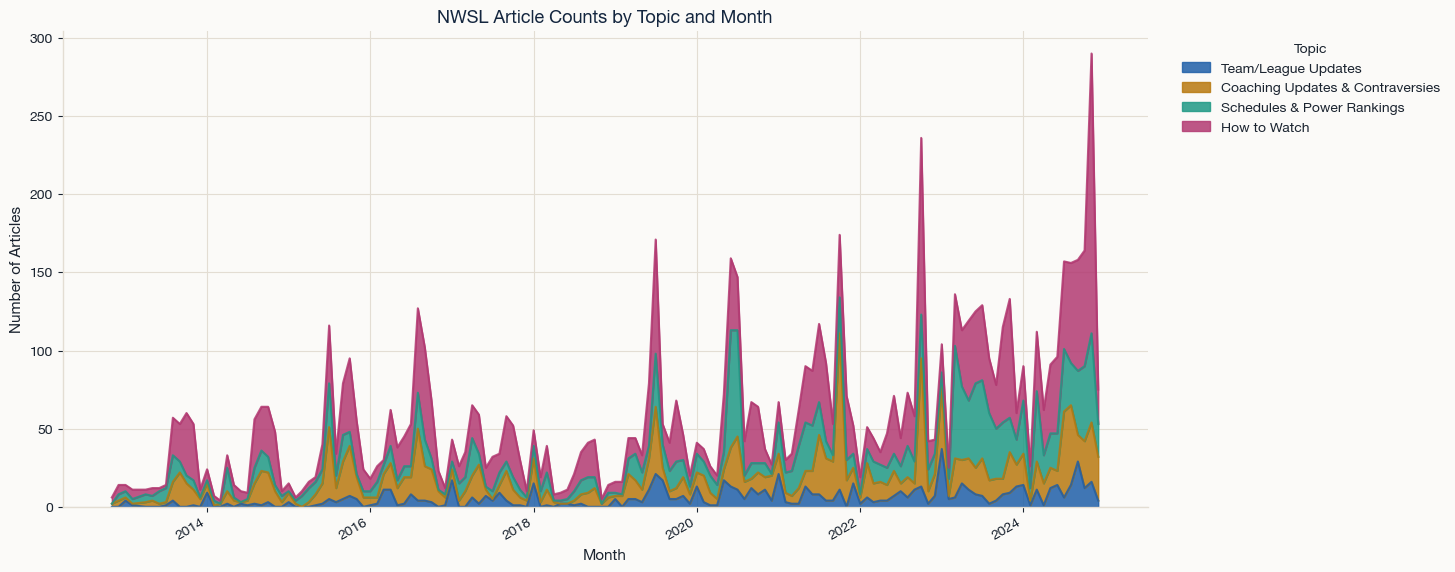

In [12]:
# 7.2 Raw counts by month (stacked area)
monthly_counts_ts = monthly_counts.copy()
monthly_counts_ts.index = monthly_counts_ts.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 7))
monthly_counts_ts.plot(
    kind="area", stacked=True, ax=ax, alpha=0.85,
    color=[TOPIC_COLORS[c] for c in monthly_counts_ts.columns],
)
ax.set_title("NWSL Article Counts by Topic and Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Articles")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left")


## 8. Which topics dominated on peak days/months?

Uses the peak-detection output from `06_media_trends_analysis.ipynb` (`monthly_peaks.csv`, `daily_peaks.csv` -- `scipy.find_peaks` on the daily/monthly article-count series, with a "prominence" score for each spike).


In [13]:
daily_peaks = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "daily_peaks.csv"))
monthly_peaks = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, "monthly_peaks.csv"))

daily_peaks["date"] = pd.to_datetime(daily_peaks["date"])
monthly_peaks["date"] = pd.to_datetime(monthly_peaks["date"])
monthly_peaks["pub_yearmonth"] = monthly_peaks["date"].dt.to_period("M")


def topic_breakdown(subset):
    """Topic counts + share for a subset of tagged articles, sorted descending."""
    if subset.empty:
        return None
    counts = subset["dominant_topic_label"].value_counts()
    shares = (counts / counts.sum()).round(3)
    return pd.DataFrame({"count": counts, "share": shares})


In [14]:
# 8.1 Daily peaks: what topic dominated on each specific spike day
daily_peak_rows = []
for _, peak in daily_peaks.iterrows():
    subset = tagged.loc[tagged["publish_date"].dt.date == peak["date"].date()]
    breakdown = topic_breakdown(subset)
    if breakdown is None:
        continue
    dominant = breakdown["count"].idxmax()
    example_titles = subset.loc[subset["dominant_topic_label"] == dominant, "title"].head(3).tolist()
    daily_peak_rows.append({
        "date": peak["date"].date(),
        "day_of_week": peak.get("day_of_week"),
        "article_count": peak["article_count"],
        "prominence": peak["prominence"],
        "dominant_topic": dominant,
        "dominant_topic_share": breakdown.loc[dominant, "share"],
        "example_titles": " | ".join(example_titles),
    })

daily_peak_summary = pd.DataFrame(daily_peak_rows).sort_values("prominence", ascending=False)
daily_peak_summary.to_csv(os.path.join(DATA_PROCESSED_DIR, "nwsl_daily_peaks_tagged.csv"), index=False)
print(f"Saved nwsl_daily_peaks_tagged.csv ({len(daily_peak_summary)} peak days)")

print("\nTop 15 daily peaks by prominence, with dominant topic that day:")
print(daily_peak_summary[
    ["date", "article_count", "prominence", "dominant_topic", "dominant_topic_share"]
].head(15).to_string(index=False))


Saved nwsl_daily_peaks_tagged.csv (333 peak days)

Top 15 daily peaks by prominence, with dominant topic that day:
      date  article_count  prominence                   dominant_topic  dominant_topic_share
2024-11-22             50        49.0                     How to Watch                 0.440
2021-10-01             39        38.0 Coaching Updates & Contraversies                 0.692
2020-06-27             31        30.0       Schedules & Power Rankings                 0.484
2019-07-10             29        28.0                     How to Watch                 0.379
2020-07-21             29        28.0 Coaching Updates & Contraversies                 0.724
2016-08-12             24        23.0 Coaching Updates & Contraversies                 0.625
2024-09-05             23        22.0 Coaching Updates & Contraversies                 0.304
2023-07-08             22        21.0       Schedules & Power Rankings                 0.545
2020-05-27             22        21.0           

In [15]:
# 8.2 Monthly peaks: same idea, at monthly granularity
monthly_peak_rows = []
for _, peak in monthly_peaks.iterrows():
    subset = tagged.loc[tagged["pub_yearmonth"] == peak["pub_yearmonth"]]
    breakdown = topic_breakdown(subset)
    if breakdown is None:
        continue
    dominant = breakdown["count"].idxmax()
    example_titles = subset.loc[subset["dominant_topic_label"] == dominant, "title"].head(3).tolist()
    monthly_peak_rows.append({
        "yearmonth": str(peak["pub_yearmonth"]),
        "article_count": peak["article_count"],
        "prominence": peak["prominence"],
        "dominant_topic": dominant,
        "dominant_topic_share": breakdown.loc[dominant, "share"],
        "example_titles": " | ".join(example_titles),
    })

monthly_peak_summary = pd.DataFrame(monthly_peak_rows).sort_values("prominence", ascending=False)
monthly_peak_summary.to_csv(os.path.join(DATA_PROCESSED_DIR, "nwsl_monthly_peaks_tagged.csv"), index=False)
print(f"Saved nwsl_monthly_peaks_tagged.csv ({len(monthly_peak_summary)} peak months)")

print("\nMonthly peaks by prominence, with dominant topic that month:")
print(monthly_peak_summary[
    ["yearmonth", "article_count", "prominence", "dominant_topic", "dominant_topic_share"]
].to_string(index=False))


Saved nwsl_monthly_peaks_tagged.csv (24 peak months)

Monthly peaks by prominence, with dominant topic that month:
yearmonth  article_count  prominence                   dominant_topic  dominant_topic_share
  2024-11            291       216.0                     How to Watch                 0.617
  2022-10            236       211.0                     How to Watch                 0.479
  2021-10            174       155.0 Coaching Updates & Contraversies                 0.575
  2019-07            171       151.0                     How to Watch                 0.427
  2020-06            159       132.0       Schedules & Power Rankings                 0.472
  2016-08            127       122.0                     How to Watch                 0.425
  2023-03            136       110.0       Schedules & Power Rankings                 0.529
  2015-07            116        98.0 Coaching Updates & Contraversies                 0.397
  2021-07            119        66.0                     

## 9. Label the significant peaks directly on the monthly-counts figure

In [16]:
# Only label the most prominent peaks so the chart doesn't get cluttered
TOP_N_PEAK_LABELS = 10
top_peaks_to_label = monthly_peak_summary.head(TOP_N_PEAK_LABELS)

y_max = monthly_counts_ts.sum(axis=1).max()

for _, peak in top_peaks_to_label.iterrows():
    peak_ts = pd.Period(peak["yearmonth"], freq="M").to_timestamp()
    if peak_ts not in monthly_counts_ts.index:
        continue
    total_that_month = monthly_counts_ts.loc[peak_ts].sum()
    ax.annotate(
        f"{peak['dominant_topic']}\n({peak['yearmonth']})",
        xy=(peak_ts, total_that_month),
        xytext=(peak_ts, total_that_month + y_max * 0.08),
        ha="center",
        fontsize=7,
        arrowprops=dict(arrowstyle="->", lw=0.8, color="black"),
    )

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nwsl_topic_counts_by_month.png"), dpi=150)
plt.show()
plt.close(fig)
print(f"Saved nwsl_topic_counts_by_month.png with top {TOP_N_PEAK_LABELS} peaks tagged by dominant topic")


<Figure size 640x480 with 0 Axes>

Saved nwsl_topic_counts_by_month.png with top 10 peaks tagged by dominant topic


## 10. What proportion of peaks are about which topic?

A different question than the trend charts above: not "how much routine coverage does each topic get overall" but "when coverage volume spikes, which topic is usually driving that spike" -- a topic can dominate peaks even if it's a minority of overall coverage.


In [17]:
daily_peak_topic_props = (
    daily_peak_summary["dominant_topic"]
    .value_counts(normalize=True)
    .reindex(TOPIC_LABELS.values())
    .fillna(0)
)
monthly_peak_topic_props = (
    monthly_peak_summary["dominant_topic"]
    .value_counts(normalize=True)
    .reindex(TOPIC_LABELS.values())
    .fillna(0)
)

print("Proportion of daily peaks by dominant topic:")
print(daily_peak_topic_props.round(3))
print("\nProportion of monthly peaks by dominant topic:")
print(monthly_peak_topic_props.round(3))

peak_topic_props = pd.DataFrame({
    "daily_peaks": daily_peak_topic_props,
    "monthly_peaks": monthly_peak_topic_props,
})
peak_topic_props.to_csv(os.path.join(DATA_PROCESSED_DIR, "nwsl_peak_topic_proportions.csv"))
print("\nSaved nwsl_peak_topic_proportions.csv")


Proportion of daily peaks by dominant topic:
dominant_topic
Team/League Updates                 0.078
Coaching Updates & Contraversies    0.213
Schedules & Power Rankings          0.243
How to Watch                        0.465
Name: proportion, dtype: float64

Proportion of monthly peaks by dominant topic:
dominant_topic
Team/League Updates                 0.042
Coaching Updates & Contraversies    0.125
Schedules & Power Rankings          0.208
How to Watch                        0.625
Name: proportion, dtype: float64

Saved nwsl_peak_topic_proportions.csv


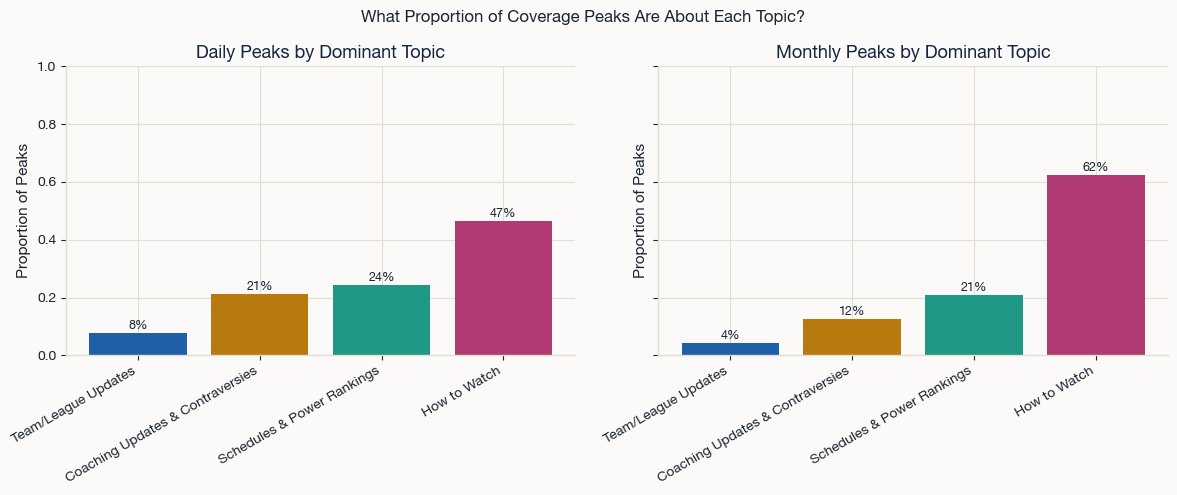

Saved nwsl_peak_topic_proportions.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax2, series, title in zip(
    axes,
    [daily_peak_topic_props, monthly_peak_topic_props],
    ["Daily Peaks", "Monthly Peaks"],
):
    bars = ax2.bar(series.index, series.values, color=[TOPIC_COLORS[label] for label in series.index])
    ax2.set_title(f"{title} by Dominant Topic")
    ax2.set_ylabel("Proportion of Peaks")
    ax2.set_ylim(0, 1)
    ax2.tick_params(axis="x", rotation=30)
    for label in ax2.get_xticklabels():
        label.set_ha("right")
    for bar, val in zip(bars, series.values):
        ax2.annotate(
            f"{val:.0%}",
            xy=(bar.get_x() + bar.get_width() / 2, val),
            xytext=(0, 3), textcoords="offset points",
            ha="center", fontsize=9,
        )

fig.suptitle("What Proportion of Coverage Peaks Are About Each Topic?")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nwsl_peak_topic_proportions.png"), dpi=150)
plt.show()
plt.close(fig)
print("Saved nwsl_peak_topic_proportions.png")
